In [ ]:
%pip install pandas matplotlib seaborn
%pip install kaggle

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
#Importamos el dataset ecommerce.data.csv y le asignamos una variable nueva (dataFrame)
dataFrame = pd.read_csv('ecommerceData.csv', encoding='latin1')

**CONOCIENDO LOS DATOS**

In [10]:
dataFrame.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2.0,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6.0,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6.0,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6.0,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32.0,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [11]:
#Cantidad de filas y columnas
dataFrame.shape

(213216, 8)

In [12]:
#Informacion de los datos y las columnas del dataset
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213216 entries, 0 to 213215
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    213216 non-null  object 
 1   StockCode    213216 non-null  object 
 2   Description  212377 non-null  object 
 3   Quantity     213215 non-null  float64
 4   InvoiceDate  213215 non-null  object 
 5   UnitPrice    213215 non-null  float64
 6   CustomerID   151804 non-null  float64
 7   Country      213215 non-null  object 
dtypes: float64(3), object(5)
memory usage: 13.0+ MB


In [13]:
dataFrame.describe()

,Quantity,UnitPrice,CustomerID
count,213215.000000,213215.000000,151804.000000
mean,9.311882,5.016050,15274.168177
std,233.381060,93.596673,1725.757266
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13821.000000
50%,3.000000,2.100000,15144.000000
75%,10.000000,4.210000,16809.000000
max,74215.000000,16888.020000,18287.000000


**GRAFICOS PARA ENTENDER MEJOR**

**LIMPIEZA DE DATOS**

In [15]:
# Ver cuántos nulos hay en cada columna
print(dataFrame.isnull().sum())

InvoiceNo          0
StockCode          0
Description      839
Quantity           1
InvoiceDate        1
UnitPrice          1
CustomerID     61412
Country            1
dtype: int64


In [16]:
# Ver el porcentaje de nulos
print(dataFrame.isnull().sum() / len(dataFrame) * 100)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.393498
Quantity        0.000469
InvoiceDate     0.000469
UnitPrice       0.000469
CustomerID     28.802716
Country         0.000469
dtype: float64


In [17]:
# Ver cuántas filas tenemos antes
print("Filas Iniciales:", len(dataFrame))

Filas Iniciales: 213216


In [18]:
# Eliminar filas donde CustomerID sea nulo (columna clave)
df = dataFrame.dropna(subset=['CustomerID', 'Description'])

In [19]:
# Ver cuántas quedaron
print("Filas después:", len(df))
print("Filas eliminadas:", len(dataFrame) - len(df))

Filas después: 151804
Filas eliminadas: 61412


In [20]:
# Convertir columna fecha(InvoiceDate) a datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Resultado
print(df['InvoiceDate'].dtype)

datetime64[ns]


/tmp/ipykernel_843/2888348934.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [21]:
#Extraer componentes de fecha para mejor manejo
df['Year']  = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day']   = df['InvoiceDate'].dt.day_name()

/tmp/ipykernel_843/1102743392.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year']  = df['InvoiceDate'].dt.year
/tmp/ipykernel_843/1102743392.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['InvoiceDate'].dt.month
/tmp/ipykernel_843/1102743392.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [22]:
# Eliminar filas donde Quantity o UnitPrice sean negativos o cero, segun la visualizacion de datos estas columnas tienen valores nulos
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [23]:
# Ingreso por línea = cantidad × precio unitario
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Resultado
df['Revenue'].describe()

,Revenue
count,148117.000000
mean,22.933059
std,214.729074
min,0.001000
25%,5.040000
50%,12.700000
75%,19.800000
max,77183.600000


In [24]:
print(" Dataset optimizado:", df.shape)
df.head()

 Dataset optimizado: (148117, 12)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,Wednesday,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,Wednesday,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,Wednesday,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,Wednesday,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,Wednesday,20.34


**ANÁLISIS DE VENTAS GENERALES: En que mes se vendio mas.**

In [25]:
#Primero: Agrupamos por año y mes y luego sumamos los ingresos
ventas_mensual = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
ventas_mensual['Periodo'] = pd.to_datetime(
    ventas_mensual[['Year', 'Month']].assign(Day=1)
)
print(ventas_mensual)

   Year  Month     Revenue    Periodo
0  2010     12  572713.890 2010-12-01
1  2011      1  569445.040 2011-01-01
2  2011      2  447137.350 2011-02-01
3  2011      3  595500.760 2011-03-01
4  2011      4  469200.361 2011-04-01
5  2011      5  678594.560 2011-05-01
6  2011      6   64183.940 2011-06-01


In [26]:
#Mes en el que se vendio mas
mejor_mes = ventas_mensual.loc[ventas_mensual['Revenue'].idxmax()]
print("Mejor mes:", mejor_mes['Periodo'].strftime('%B %Y'))
print("Ingreso:", f"${mejor_mes['Revenue']:,.2f}")

Mejor mes: May 2011
Ingreso: $678,594.56


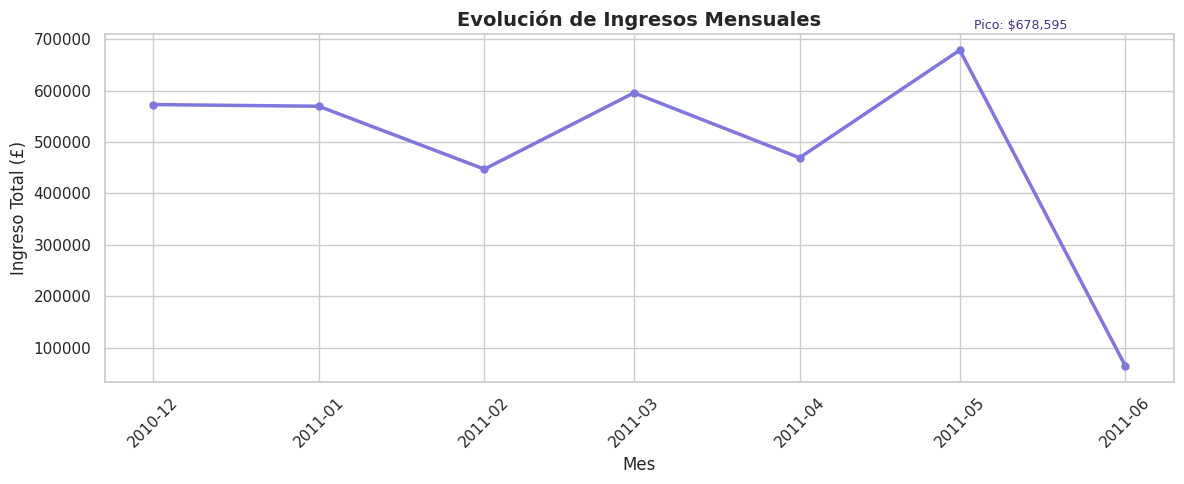

In [27]:
#Grafico Lineal de Evolucion mensual
plt.plot(
    ventas_mensual['Periodo'],
    ventas_mensual['Revenue'],
    color='#7F77DD', linewidth=2.5, marker='o', markersize=5
)

pico = ventas_mensual.loc[ventas_mensual['Revenue'].idxmax()]
plt.annotate(
    f"Pico: ${pico['Revenue']:,.0f}",
    xy=(pico['Periodo'], pico['Revenue']),
    xytext=(10, 15), textcoords='offset points',
    fontsize=9, color='#3C3489'
)

plt.title('Evolución de Ingresos Mensuales', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Ingreso Total (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ventas_mensuales.png', dpi=150)
plt.show()

**ANALISIS DE PRODUCTOS**

In [28]:
#TOP 10 DE PRODUCTOS MAS VENDISO POR CANTIDAD
top_cantidad = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top_cantidad)

                          Description  Quantity
0      MEDIUM CERAMIC TOP STORAGE JAR   75055.0
1   WORLD WAR 2 GLIDERS ASSTD DESIGNS   29236.0
2  WHITE HANGING HEART T-LIGHT HOLDER   20810.0
3     PACK OF 72 RETROSPOT CAKE CASES   18663.0
4             JUMBO BAG RED RETROSPOT   18457.0
5                SMALL POPCORN HOLDER   17282.0
6       ASSORTED COLOUR BIRD ORNAMENT   13691.0
7          PACK OF 12 LONDON TISSUES    13000.0
8  PACK OF 60 PINK PAISLEY CAKE CASES   12925.0
9           ASSORTED COLOURS SILK FAN   12072.0


In [29]:
# TOP 10 DE PRODUCTOS POR INGRESO
top_ingresos = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top_ingresos)

                          Description   Revenue
0            REGENCY CAKESTAND 3 TIER  79390.35
1      MEDIUM CERAMIC TOP STORAGE JAR  78112.64
2  WHITE HANGING HEART T-LIGHT HOLDER  56150.02
3                             POSTAGE  35022.70
4                       PARTY BUNTING  33687.35
5             JUMBO BAG RED RETROSPOT  32963.86
6       ASSORTED COLOUR BIRD ORNAMENT  22204.67
7                              Manual  20076.17
8                       CHILLI LIGHTS  19472.06
9        VINTAGE UNION JACK MEMOBOARD  17890.93


/tmp/ipykernel_843/2529372981.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


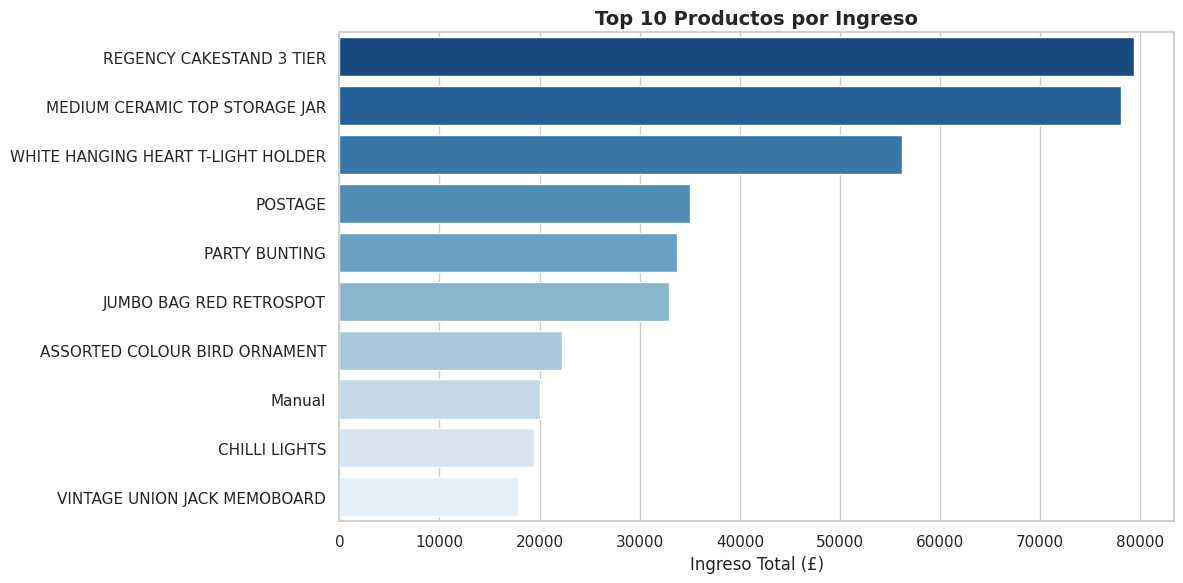

In [30]:
# GRAFICO DE EL TOP 10 DE PRODUCTOS CON MAYOR INGRESO
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_ingresos,
    x='Revenue', y='Description',
    palette='Blues_r'
)

plt.title('Top 10 Productos por Ingreso', fontsize=14, fontweight='bold')
plt.xlabel('Ingreso Total (£)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('top_productos.png', dpi=150)
plt.show()

In [31]:
# REGLA 80/20: PRODUCTOS QUE GENERAN EL 80% DE INGRESOS
productos_revenue = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

total = productos_revenue['Revenue'].sum()
productos_revenue['Porcentaje'] = productos_revenue['Revenue'] / total * 100
productos_revenue['Acumulado'] = productos_revenue['Porcentaje'].cumsum()


pareto = productos_revenue[productos_revenue['Acumulado'] <= 80]
print(f"Productos que generan el 80% de ingresos: {len(pareto)}")
print(f"De un total de {len(productos_revenue)} productos")
print(f"Eso es el {len(pareto)/len(productos_revenue)*100:.1f}% del catálogo")

Productos que generan el 80% de ingresos: 656
De un total de 3213 productos
Eso es el 20.4% del catálogo


**ANALISIS DE CLIENTES**

In [32]:
# TOTAL DE CLIENTES UNICOS
clientes_unicos = df['CustomerID'].nunique()
print(f"Clientes únicos: {clientes_unicos}")

Clientes únicos: 2747


In [33]:
# PROMEDIO DE COMPRA DE CADA CLIENTE
gasto_por_cliente = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Revenue': 'GastoTotal'})
)

print(f"Gasto promedio por cliente: £{gasto_por_cliente['GastoTotal'].mean():,.2f}")
print(f"Mediana de gasto: £{gasto_por_cliente['GastoTotal'].median():,.2f}")
print(f"Cliente que más gastó: £{gasto_por_cliente['GastoTotal'].max():,.2f}")


Gasto promedio por cliente: £1,236.54
Mediana de gasto: £477.79
Cliente que más gastó: £116,135.92


In [34]:
# TOP 10 PAISES QUE COMPRAN MAS
paises = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(paises)

          Country      Revenue
0  United Kingdom  2778328.791
1     Netherlands   118829.080
2         Germany    97433.910
3            EIRE    86071.640
4          France    73606.430
5       Australia    56379.980
6           Spain    24715.120
7           Japan    21434.730
8        Portugal    16260.410
9          Sweden    16163.330


/tmp/ipykernel_843/2324161477.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


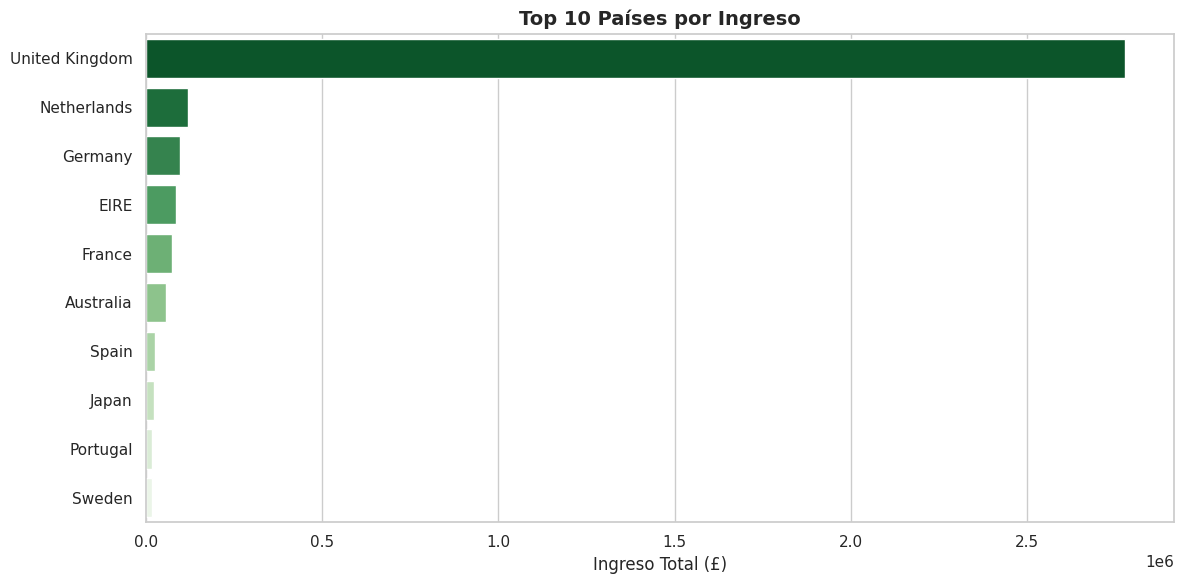

In [35]:
# GRAFICO DEL TOP 10 DE PAISES QUE MAS COMPRAN
plt.figure(figsize=(12, 6))

sns.barplot(
    data=paises,
    x='Revenue', y='Country',
    palette='Greens_r'
)

plt.title('Top 10 Países por Ingreso', fontsize=14, fontweight='bold')
plt.xlabel('Ingreso Total (£)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('paises.png', dpi=150)
plt.show()